In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import scipy.stats as ss

In [2]:
d1000 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_1000middle.csv")
d1250 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_1250middle.csv")
d1500 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_middle.csv")
d1750 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_1750middle.csv")
d2000 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_2000middle.csv")
d2250 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_2250middle.csv")
d2500 = pd.read_csv("./outputs/sim_hist_18000_50y_10m_2500middle.csv")

ratings = [1000, 1250, 1500, 1750, 2000, 2250, 2500]
data = [d1000, d1250, d1500, d1750, d2000, d2250, d2500]

YEARS = 50

In [3]:
uniform = pd.read_csv("./outputs/sim_hist_18000_50y_10m_extreme.csv")

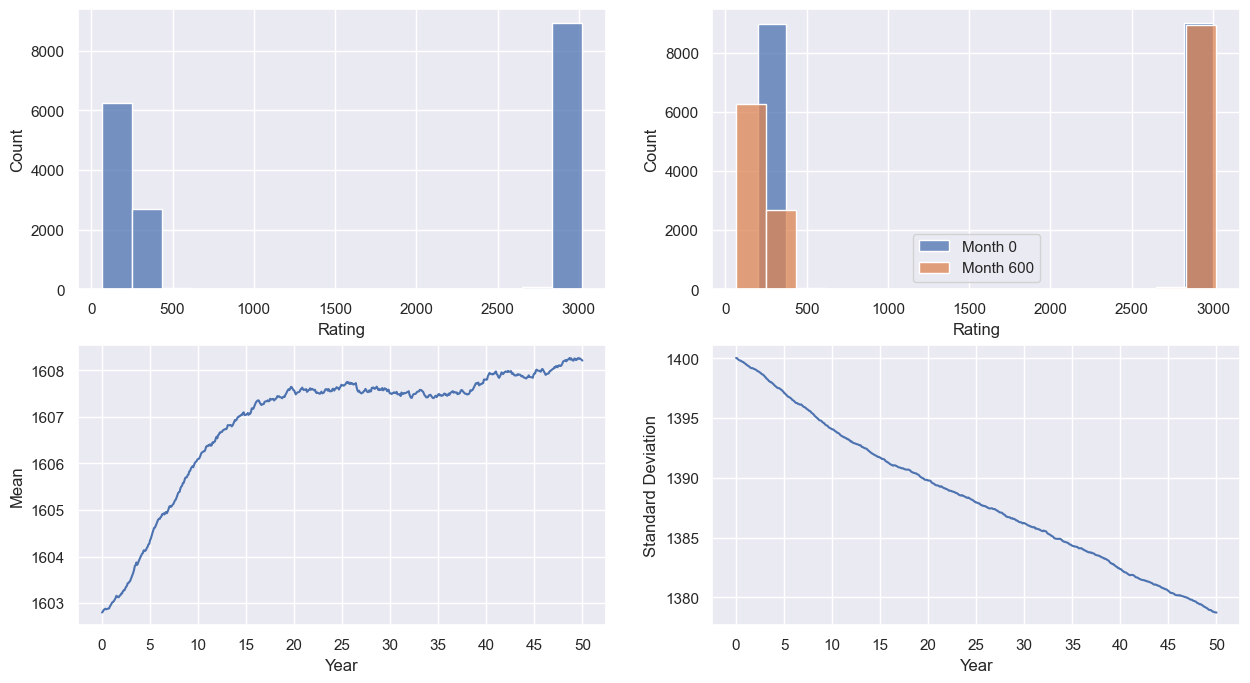

In [4]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=uniform, x=f"Month {YEARS * 12}")
plt.xlabel("Rating")

plt.subplot(2, 2, 2)
sns.histplot(data=uniform, x="Month 0", label="Month 0")
sns.histplot(
    data=uniform, x=f"Month {YEARS * 12}", label=f"Month {YEARS * 12}"
)
plt.legend()
plt.xlabel("Rating")

plt.subplot(2, 2, 3)
sns.lineplot(data=uniform.mean(axis=0))
plt.xlabel("Year")
plt.ylabel("Mean")
plt.xticks(np.arange(0, YEARS * 12 + 1, 60), np.arange(0, YEARS + 1, 5))

plt.subplot(2, 2, 4)
sns.lineplot(data=uniform.std(axis=0))
plt.xlabel("Year")
plt.ylabel("Standard Deviation")
plt.xticks(np.arange(0, YEARS * 12 + 1, 60), np.arange(0, YEARS + 1, 5))

plt.show()


In [53]:
v1000 = d1000.var(axis=0)
v1250 = d1250.var(axis=0)
v1500 = d1500.var(axis=0)
v1750 = d1750.var(axis=0)
v2000 = d2000.var(axis=0)
v2250 = d2250.var(axis=0)
v2500 = d2500.var(axis=0)

In [54]:
variances = []

for df in data:
    variances.append(df.var(axis=0))

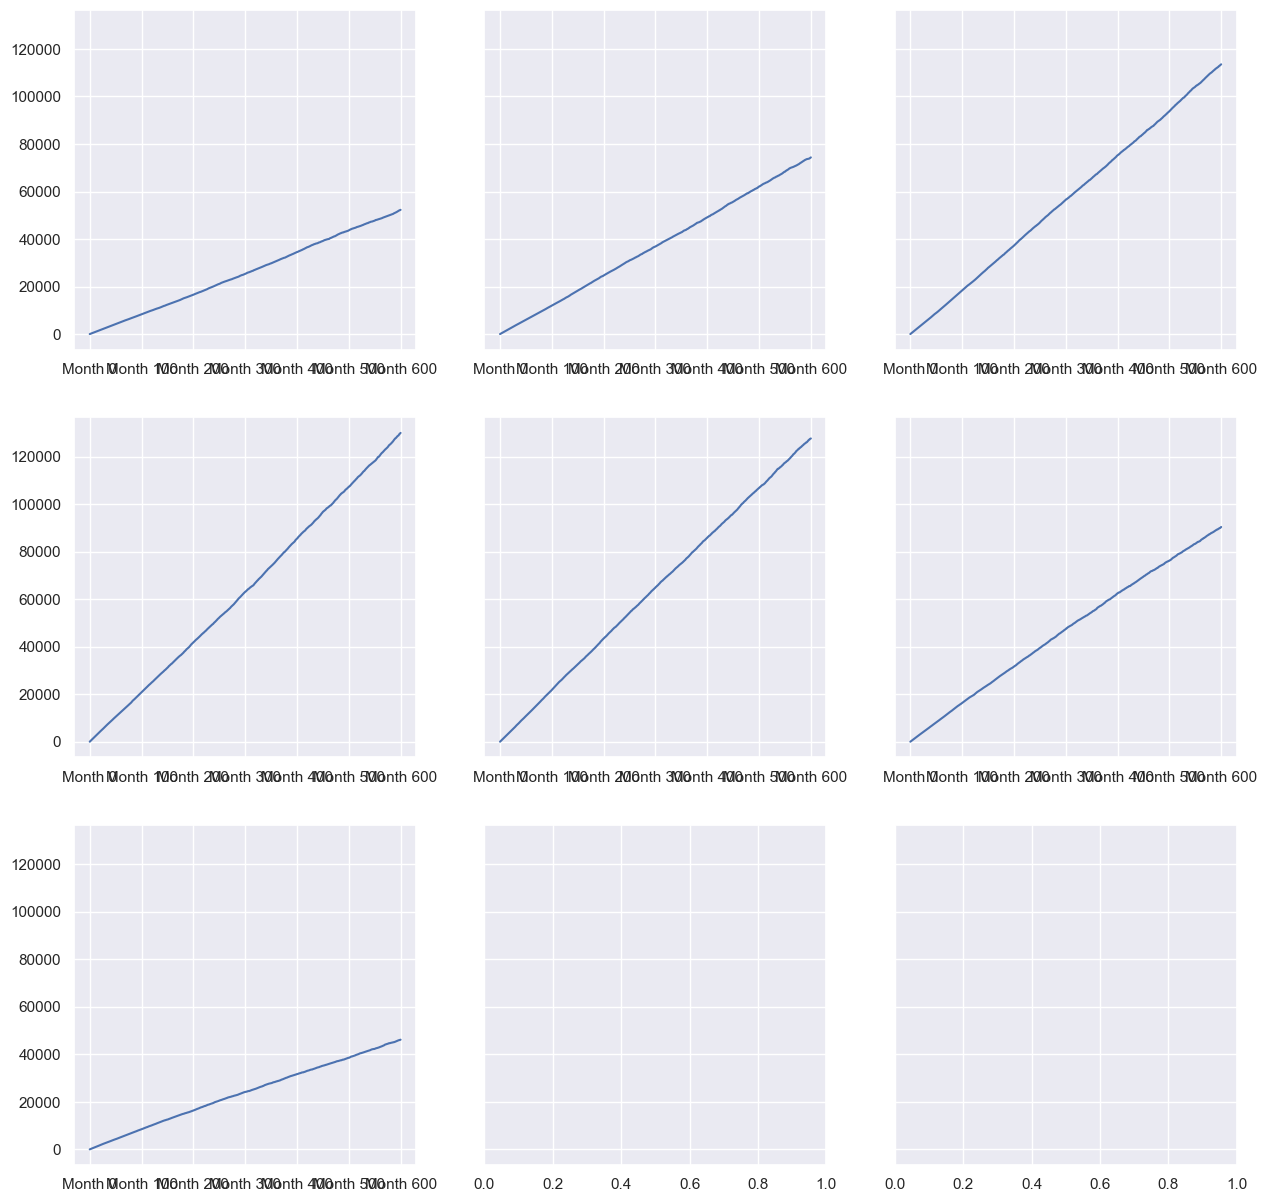

In [55]:
fig, axes = plt.subplots(3, 3, sharey=True, figsize=(15, 15))

for i in range(len(variances)):
    variances[i].plot(ax=axes[i//3][i%3])

In [56]:
slope1000 = ss.linregress(x=np.arange(YEARS*12+1), y=v1000.values).slope
slope1500 = ss.linregress(x=np.arange(YEARS*12+1), y=v1500.values).slope
slope2000 = ss.linregress(x=np.arange(YEARS*12+1), y=v2000.values).slope

In [57]:
slopes = []

for variance in variances:
    slopes.append(ss.linregress(x=np.arange(YEARS*12+1), y=variance.values).slope)

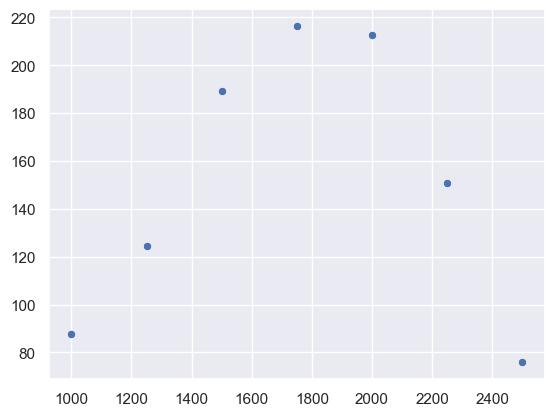

In [58]:
sns.scatterplot(x=ratings, y=slopes)
plt.show()